In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoProcessor, AutoModelForImageTextToText

# Load model directly
processor = AutoProcessor.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero")
model = AutoModelForImageTextToText.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero"
                                                    ,torch_dtype="auto", device_map="auto")
model.eval()

# Prepare image input
image_url = "https://multimodal-r1.s3.us-west-1.amazonaws.com/demo_image.jpg"

# Prepare text input
question = "Considering the relative positions of the sofa and the picture in the image provided, where is the sofa located with respect to the picture? Select from the following choices.\n(A) above or \n(B) below"
prompt = f"A conversation between User and Assistant. The user asks a question about the image, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\nUser: {question} \nAssistant: Let me solve this step by step.\n<think>"

# Create Message
message = [

                        {
                            "type": "image",
                            "image": image_url,
                        },
                        {"type": "text", "text": "<image>" + prompt},
                    ]

# Process input
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
text = processor.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
input = processor(
                text=text,
                image=image,
                padding=True,
                return_tensors="pt",
            )
input = input.to("cuda")

# Generation of the output
generated_ids = model.generate(**input, use_cache=True, max_new_tokens=1024, do_sample=True)
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(input.input_ids, generated_ids)
]
batch_output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

# Get output
output_text = batch_output_text[0]
print(output_text)


/clifford-data/home/doyoonkim/miniconda3/envs/doyoon/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.60s/it]
Keyword argument `image` is not a valid argument for this processor and will be ignored.


 The sofa is located above the picture.</think>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>above</answer>
<answer>a

In [3]:
import torch
torch.cuda.is_available()

True

In [4]:
import matplotlib.pyplot as plt
# Prepare image input
image_url = "https://multimodal-r1.s3.us-west-1.amazonaws.com/demo_image.jpg"
import requests
image = requests.get(image_url)


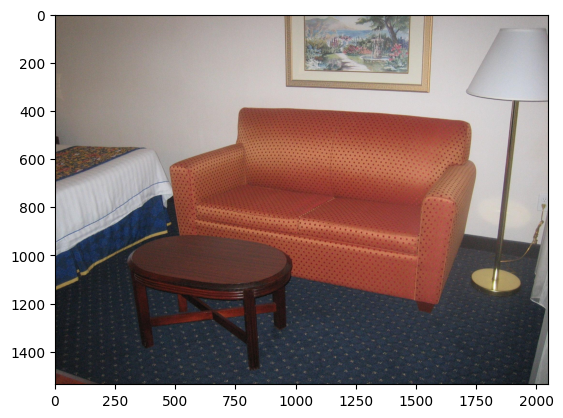

In [5]:
from PIL import Image
from io import BytesIO

image = Image.open(BytesIO(image.content))
plt.imshow(image)

In [6]:
import torchvision
import torch
from typing import Tuple, List

ds = torchvision.datasets.CIFAR10('./', train=False, download=True)
classes = ds.classes
batch =8

def collate_fn(batch):
    imgs, labels = zip(*batch)
        # print(labels)
    return list(imgs), list(labels)

dl = torch.utils.data.DataLoader(
    ds, batch_size=batch, shuffle=True, collate_fn=collate_fn
)


In [7]:
a = [(1,1),(2,2)]
c,d = zip(*a)
c, d

((1, 2), (1, 2))

In [8]:
ds = torchvision.datasets.CIFAR10('./', train=False, download=True)
classes = ds.classes
batch = 1

def collate_fn(batch):
    imgs, labels = zip(*batch)
    return list(imgs), list(labels)

dl = torch.utils.data.DataLoader(
    ds, batch_size=batch, shuffle=True, collate_fn=collate_fn
)

In [9]:
# ----------------------------------------------------
# 2. 모델 로드 (이전 코드와 동일)
# ----------------------------------------------------
print("모델 로딩 중...")
processor = AutoProcessor.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero")
model = AutoModelForImageTextToText.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero",
                                                    torch_dtype="auto", device_map="auto")
model.eval() # 모델을 평가 모드로 설정

# 모델이 GPU에 로드되었는지 확인
device = model.device
print(f"모델의 최종 디바이스: {device}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
print(f"CUDA 디바이스 수: {torch.cuda.device_count()}")

모델 로딩 중...


Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.28s/it]


모델의 최종 디바이스: cuda:0
CUDA 사용 가능 여부: True
CUDA 디바이스 수: 1


In [10]:
# ----------------------------------------------------
# 3. 인퍼런스 루프
# ----------------------------------------------------
print("\n인퍼런스 시작...")
# 인퍼런스 시에는 기울기 계산을 비활성화하여 메모리 사용량과 계산 시간을 줄입니다.
with torch.no_grad():
    for i, (images_batch, labels_batch) in enumerate(dl):
        print(f"\n--- 배치 {i+1} 처리 중 ---")

        # DataLoader에서 얻은 이미지와 레이블을 모델의 입력 형식에 맞게 준비합니다.
        # VisualThinker-R1-Zero 모델은 이미지와 텍스트(질문)를 함께 입력받습니다.
        # 여기서는 CIFAR10 이미지를 입력으로 사용하고, 질문은 일반적인 질문을 사용하겠습니다.
        # 실제 시나리오에서는 각 이미지에 맞는 질문이 필요할 수 있습니다.

        # 임시로 사용할 질문 (CIFAR10 이미지에 대한 일반적인 질문)
        # 실제 사용 시에는 이미지 내용과 관련된 적절한 질문을 구성해야 합니다.
        question = "What is the main object in this image? Select from the following choices.\n(A) airplane or \n(B) automobile or \n(C) bird or \n(D) cat or \n(E) deer or \n(F) dog or \n(G) frog or \n(H) horse or \n(I) ship or \n(J) truck"
        prompt = f"A conversation between User and Assistant. The user asks a question about the image, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\nUser: {question} \nAssistant: Let me solve this step by step.\n<think>"

        # 각 이미지에 대해 텍스트 입력을 준비 (동일한 질문 사용)
        # processor.apply_chat_template은 텍스트를 하나로 합치고 토크나이징에 적합하게 만듭니다.
        # 여기서는 각 이미지에 대해 동일한 텍스트 프롬프트를 사용할 것입니다.
        # batch_size가 1이라면 하나의 `image`와 `text`를 사용하면 됩니다.
        # 배치를 처리하려면 `processor`의 `batch_encode_plus` 또는 유사한 배치 처리 메서드를 사용해야 할 수 있습니다.

        # transformers 모델의 processor는 리스트 형태의 이미지를 처리할 수 있습니다.
        # 텍스트는 모든 이미지에 대해 동일하게 적용됩니다.
        text_inputs = [prompt] * len(images_batch) # 모든 이미지에 동일한 질문 적용

        # 입력 데이터 전처리
        # `processor`가 배치 이미지와 텍스트를 처리하는 방법을 확인해야 합니다.
        # 일반적으로 `processor(images=list_of_images, text=list_of_texts, ...)` 형태입니다.
        try:
            input_data = processor(
                images=images_batch, # collate_fn에서 이미지를 리스트로 반환했으므로 직접 전달
                text=text_inputs,
                padding="longest",   # 배치 내에서 가장 긴 시퀀스에 맞춰 패딩
                return_tensors="pt", # PyTorch 텐서로 반환
            )
        except Exception as e:
            print(f"Processor 입력 처리 중 오류 발생: {e}")
            print("VisualThinker-R1-Zero 모델의 배치 입력 형식에 대한 자세한 문서를 확인해 보세요.")
            # 오류 발생 시, `processor`가 기대하는 입력 형식과 `images_batch` 및 `text_inputs`의 형식을 비교해 보세요.
            continue # 다음 배치로 넘어갑니다.


        # 데이터를 모델이 있는 장치로 이동
        # device_map="auto"를 사용했기 때문에 모델이 이미 GPU에 분산되어 있을 가능성이 높습니다.
        # 하지만 입력 텐서는 수동으로 이동시켜야 합니다.
        input_data = {k: v.to(device) for k, v in input_data.items()}

        # 모델 인퍼런스 수행
        generated_ids = model.generate(**input_data, use_cache=True, max_new_tokens=1024, do_sample=True)

        # 생성된 ID에서 입력 ID를 제거하여 실제 생성된 부분만 남깁니다.
        # `input_ids`와 `attention_mask`만 사용하는 것이 일반적입니다.
        # `processor.batch_decode`를 사용하여 텍스트로 변환합니다.
        # VisualThinker의 경우 `processor.apply_chat_template`으로 생성된 텍스트는
        # 모델 입력에 <image> 토큰과 프롬프트가 포함되어 있습니다.
        # 따라서 생성된 ID에서 입력 ID만큼 잘라내는 로직이 필요합니다.
        
        # NOTE: `input_data.input_ids`는 토크나이징된 전체 프롬프트 길이입니다.
        # 생성된 텍스트는 이 길이를 넘어서는 부분입니다.
        generated_ids_trimmed = []
        for i_in, i_gen in zip(input_data.input_ids, generated_ids):
            # 입력 ID의 길이를 기준으로 잘라냅니다.
            # `generation_config`에 따라 `bos_token_id`나 `eos_token_id`가 추가될 수 있으므로,
            # 정확한 시작점을 찾기 위해 조금 더 복잡한 로직이 필요할 수 있습니다.
            # 여기서는 간단히 입력 길이만큼 자릅니다.
            generated_ids_trimmed.append(i_gen[len(i_in):])

        batch_output_text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )

        # 결과 출력 (배치 내 각 이미지에 대한 답변)
        for j, output_text in enumerate(batch_output_text):
            print(f"  이미지 {j+1} (레이블: {classes[labels_batch[j]]}):")
            print(f"    생성된 답변: {output_text.strip()}")

        # 첫 번째 배치만 확인하고 싶다면 break
        # break


인퍼런스 시작...

--- 배치 1 처리 중 ---


ValueError: Image features and image tokens do not match: tokens: 0, features 4

In [11]:
import os
import torch
import torchvision
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoProcessor, AutoModelForImageTextToText
from typing import Tuple, List

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,5,6,7,8,9"

# ----------------------------------------------------
# 1. 데이터셋 및 DataLoader 설정
#    >>> batch_size를 1로 변경합니다. <<<
# ----------------------------------------------------
ds = torchvision.datasets.CIFAR10('./', train=False, download=True)
classes = ds.classes
batch_size = 1 # 변경된 부분!

def collate_fn(batch_data: List[Tuple[Image.Image, int]]) -> Tuple[List[Image.Image], List[int]]:
    """
    DataLoader가 각 배치를 어떻게 묶을지 정의합니다.
    (이미지, 레이블) 튜플 리스트를 받아서 이미지 리스트와 레이블 리스트로 분리합니다.
    """
    imgs, labels = zip(*batch_data)
    return list(imgs), list(labels)

dl = torch.utils.data.DataLoader(
    ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
)

# ----------------------------------------------------
# 2. 모델 로드
# ----------------------------------------------------
print("모델 로딩 중...")
processor = AutoProcessor.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero")
model = AutoModelForImageTextToText.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero",
                                                    torch_dtype="auto", device_map="auto")
model.eval()

device = model.device
print(f"모델의 최종 디바이스: {device}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
print(f"CUDA 디바이스 수: {torch.cuda.device_count()}")

# ----------------------------------------------------
# 3. 인퍼런스 루프
# ----------------------------------------------------
print("\n인퍼런스 시작...")
with torch.no_grad():
    # 단일 배치를 가져옵니다. (batch_size=1 이므로 한 번에 하나의 이미지/레이블)
    for i, (images_batch, labels_batch) in enumerate(dl):
        print(f"\n--- 배치 {i+1} 처리 중 ---")

        # images_batch와 labels_batch는 각각 길이가 1인 리스트입니다.
        image = images_batch[0]
        label = labels_batch[0]
        true_class_name = classes[label]

        question = f"What is the main object in this image? Select from the following choices.\n(A) airplane or \n(B) automobile or \n(C) bird or \n(D) cat or \n(E) deer or \n(F) dog or \n(G) frog or \n(H) horse or \n(I) ship or \n(J) truck. The object is a {true_class_name}."
        prompt = f"A conversation between User and Assistant. The user asks a question about the image, and the Assistant solves it. The assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\nUser: {question} \nAssistant: Let me solve this step by step.\n<think>"

        # 단일 이미지와 텍스트를 processor에 전달
        # processor는 이미지를 포함한 전체 채팅 템플릿을 생성합니다.
        text = processor.apply_chat_template([{"type": "image", "image": "image"}, {"type": "text", "text": prompt}],
                                              tokenize=False, add_generation_prompt=True)

        input_data = processor(
            text=text,
            images=image, # 단일 이미지 객체 전달
            padding="longest",
            return_tensors="pt",
        )

        input_data = {k: v.to(device) for k, v in input_data.items()}

        generated_ids = model.generate(**input_data, use_cache=True, max_new_tokens=1024, do_sample=True)

        # 입력 ID를 잘라내는 로직은 이전과 동일
        generated_ids_trimmed = []
        for i_in, i_gen in zip(input_data.input_ids, generated_ids):
            generated_ids_trimmed.append(i_gen[len(i_in):])

        batch_output_text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )

        output_text = batch_output_text[0]
        print(f"  이미지 (실제 레이블: {true_class_name}):")
        print(f"    생성된 답변: {output_text.strip()}")

        # 첫 번째 배치만 확인하고 싶다면 break
        break

모델 로딩 중...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.51it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


모델의 최종 디바이스: cuda:0
CUDA 사용 가능 여부: True
CUDA 디바이스 수: 1

인퍼런스 시작...

--- 배치 1 처리 중 ---


KeyboardInterrupt: 

In [13]:

import os
import torch
import torchvision
from PIL import Image
# import requests # requests와 BytesIO는 URL 이미지 로드 시 필요, 여기서는 로컬 데이터셋 사용
# from io import BytesIO
from transformers import AutoProcessor, AutoModelForImageTextToText
from typing import Tuple, List

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,5,6,7,8,9" # 사용 가능한 GPU에 맞게 조절

# ----------------------------------------------------
# 1. 데이터셋 및 DataLoader 설정
# ----------------------------------------------------
ds = torchvision.datasets.CIFAR10('./', train=False, download=True)
classes = ds.classes
batch_size = 1

def collate_fn(batch_data: List[Tuple[Image.Image, int]]) -> Tuple[List[Image.Image], List[int]]:
    imgs, labels = zip(*batch_data)
    return list(imgs), list(labels)

dl = torch.utils.data.DataLoader(
    ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
)

# ----------------------------------------------------
# 2. 모델 로드
# ----------------------------------------------------
print("모델 로딩 중...")
processor = AutoProcessor.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero")
model = AutoModelForImageTextToText.from_pretrained("turningpoint-ai/VisualThinker-R1-Zero",
                                                    torch_dtype="auto", device_map="auto")
model.eval()

device = model.device
print(f"모델의 최종 디바이스: {device}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
print(f"CUDA 디바이스 수: {torch.cuda.device_count()}")

# ----------------------------------------------------
# 3. 인퍼런스 루프
# ----------------------------------------------------
print("\n인퍼런스 시작...")
with torch.no_grad():
    for i, (images_batch, labels_batch) in enumerate(dl):
        if i >= 5: # 예시로 5개 이미지만 테스트
            print("\n5개 이미지 처리를 완료하여 루프를 종료합니다.")
            break
        print(f"\n--- 배치 {i+1} 처리 중 ---")

        image = images_batch[0]
        label = labels_batch[0]
        true_class_name = classes[label]

        # --- 프롬프트 수정 ---
        # 1. 질문에서 정답 힌트 제거
        # 2. 모델이 클래스 이름만 간단히 답하도록 질문 수정
        class_options_str = ", ".join(classes)
        question = f"What is the main object in this image? Choose one word from these options: {class_options_str}."

        # 3. 프롬프트에서 불필요한 설명 및 <think> 토큰 제거
        #    모델이 바로 답변을 생성하도록 "Assistant:" 뒤를 비워둡니다.
        #    기존 코드의 `apply_chat_template` 사용 방식과 `add_generation_prompt=True`를 고려하면,
        #    `prompt` 문자열은 대화의 내용을 담고, `add_generation_prompt=True`가 Assistant의 생성을 시작하는 역할을 합니다.
        #    따라서 `prompt`는 User의 말까지만 포함하거나, Assistant의 시작부분까지만 포함하는 것이 일반적입니다.
        #    VisualThinker 모델의 정확한 기대 형식에 따라 미세 조정이 필요할 수 있습니다.
        #    여기서는 원래 코드의 구조를 최대한 유지하면서 내용을 단순화합니다.
        #    "A conversation..." 부분도 모델의 학습 방식에 따라 필요할 수 있으나, 최소화해봅니다.
        #    가장 간단하게는 User의 질문과 Assistant의 답변 시작점만 명시합니다.
        
        # 새로운 프롬프트 문자열 (모델이 User의 질문에 대한 답변을 바로 생성하도록 유도)
        # VisualThinker가 대화형식에 잘 튜닝되어 있다면 아래와 같은 형식이 잘 동작할 수 있습니다.
        prompt_text_for_template = f"User: {question}\nAssistant:"

        # processor.apply_chat_template은 모델별 특화된 방식으로 프롬프트를 구성합니다.
        # VisualThinker의 경우, 이미지와 텍스트를 함께 처리하기 위한 특별한 입력 형식을 사용합니다.
        # 원래 코드에서 `prompt` 변수가 대화 전체(User턴, Assistant 턴 시작부분)를 포함했으므로,
        # `prompt_text_for_template`를 그 자리에 사용합니다.
        text = processor.apply_chat_template(
            [{"type": "image", "image": "image"}, {"type": "text", "text": prompt_text_for_template}],
            tokenize=False,
            add_generation_prompt=True # True로 두면 processor가 Assistant의 답변 생성을 위한 토큰을 추가할 수 있음
                                      # 만약 prompt_text_for_template가 이미 Assistant: 로 끝난다면,
                                      # 이 옵션이 어떻게 동작하는지 모델/프로세서마다 다를 수 있으나 보통은 잘 처리합니다.
        )

        input_data = processor(
            text=text,
            images=image,
            padding="longest",
            return_tensors="pt",
        )
        # Ensure all parts of input_data are on the correct device
        input_data = {k: v.to(device) for k, v in input_data.items()}

        generated_ids = model.generate(**input_data, use_cache=True, max_new_tokens=10, do_sample=False)

        generated_ids_trimmed = []
        # --- MODIFIED LINE ---
        # Access 'input_ids' using dictionary key access
        for i_in, i_gen in zip(input_data['input_ids'], generated_ids):
            generated_ids_trimmed.append(i_gen[len(i_in):])

        batch_output_text = processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=True
        )

        output_text = batch_output_text[0].strip()
        print(f"  이미지 (실제 레이블: {true_class_name})")
        print(f"    예측된 답변: {output_text}")

        # # 첫 번째 배치만 확인하고 싶다면 아래 주석 해제
        # break

모델 로딩 중...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.76it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


모델의 최종 디바이스: cuda:0
CUDA 사용 가능 여부: True
CUDA 디바이스 수: 1

인퍼런스 시작...

--- 배치 1 처리 중 ---
  이미지 (실제 레이블: deer)
    예측된 답변: The main object in this image is a deer.

--- 배치 2 처리 중 ---
  이미지 (실제 레이블: horse)
    예측된 답변: The main object in this image is a horse.

--- 배치 3 처리 중 ---
  이미지 (실제 레이블: airplane)
    예측된 답변: The main object in this image is a ship.

--- 배치 4 처리 중 ---
  이미지 (실제 레이블: horse)
    예측된 답변: The main object in this image is a horse.

--- 배치 5 처리 중 ---
  이미지 (실제 레이블: bird)
    예측된 답변: The main object in this image is a bird.

5개 이미지 처리를 완료하여 루프를 종료합니다.
